# 04_NarrativeRisk_DeltaSeverity

Same tercile-sort + FF5+UMD pipeline as quantlet 01 but the cross-sectional signal is the year-over-year change in composite_severity per firm rather than the level. Tests whether the predictive content of the language-intensity signal lies in its absolute level or in its first difference. The first fiscal year per firm is dropped because no t-1 baseline exists, reducing the panel by approximately 30 firm-year cells. Indicative not inferential.

**Axis exercised:** Level vs change in composite severity

Headline numbers reported below are **indicative not inferential** at N=30 firms x 10 fiscal years and are **not intended as evidence**.


## Motivation: level versus change in disclosure severity

Quantlet 01 sorts firms each year on the **level** of their composite risk-disclosure severity: a firm whose 10-K reads as uniformly intense across the ten themes ranks high every year that pattern persists.
This quantlet sorts on the **year-over-year change** in that same composite signal instead: the cross-sectional ranking is determined by how much a firm's disclosure language intensified or eased between two consecutive filings.

The motivation is the standard level-versus-change distinction in panel signal design.
A level signal captures persistent cross-sectional differences: some firms are structurally more risk-disclosing than others, and the level sort picks up that long-run heterogeneity.
A change signal removes the firm-specific level and isolates the news content of each year's filing: a firm whose composite severity rose from 1.5 to 2.5 between 2018 and 2019 receives a strong positive change signal regardless of whether 2.5 is high or low in absolute terms.

Three reasons make the change signal worth measuring separately.

First, market efficiency arguments cut differently for the two signals.
The level may already be priced in: investors who follow a firm year after year know that its 10-K reads as risk-intense, and that knowledge is presumably embedded in the equity price.
The change is closer to a news shock: a sharp year-over-year shift in disclosure language is a fresh signal that arrives with each new filing and may take time to be incorporated into prices.

Second, the change signal is mechanically less correlated across firms within the same sector or vintage.
Two firms in the same sector may both score high on the level signal because both face common sector risks; their changes may move in opposite directions because each firm's filing reflects its own incremental adjustment to the prior-year baseline.
A change-based sort therefore tests a partially orthogonal cross-sectional dimension to the level-based sort.

Third, the comparison between this quantlet's headline alpha and quantlet 01's headline alpha is itself the diagnostic.
If both deliver similar magnitudes, the level and change signals carry similar information.
If one delivers a meaningfully larger alpha or the alphas have opposite signs, the disagreement is the empirically useful finding for this pair.

The structural setting matches quantlet 01 exactly: the 30 largest S&P 500 constituents by market capitalisation at the end of 2014, observed annually from fiscal year 2015 through fiscal year 2024.
The first fiscal year per firm is dropped from the change panel because no t-1 baseline exists, reducing the firm-year panel by about 30 cells (from roughly 300 to roughly 270).


## Methodology

```
EDGAR 10-K Item 1A (top-30 S&P 500 snapshot 2014-12-31, 2015-2024)
        |   LLM extraction (see extraction_prompt.md)
        v
corpus.ndjson.gz (~3000 records: 30 firms x 10 years x 10 themes, severity 0-5)
        |   compute_theme_exposures (mean across 10 themes)
        v
composite_severity per (firm, signal_year)
        |   form_terciles_with_lag (signal_year y-1 -> portfolio_year y)
        v
tercile (or decile) assignments + monthly returns
        |   axis-specific transform: Level vs change in composite severity
        v
delta_severity_summary.csv + figure(s)
```


## Corpus and scoring pipeline

The raw corpus is identical to quantlet 01.
30 firms, 10 fiscal years (2015-2024), and 10 thematic categories produce a 30 x 10 x 10 panel of integer severity scores in the range 0 to 5.
Severities are produced by passing the Item 1A section of each 10-K through a large language model with the prompt defined in `extraction_prompt.md`.
Each record carries an `evidence_quote` column reproducing the verbatim passage that motivated the score, and a companion `provenance.json` records the model version, prompt hash, extraction date, and a SHA-256 checksum of `corpus.ndjson.gz`.

The 10 themes are: supply chain, regulatory, cyber, macro, climate, competition, litigation, talent, input cost, and technology.
This taxonomy is hand-listed for illustrative purposes; a production deployment would derive the theme list from a data-driven topic model trained on a broader corpus.

Two pipeline stages distinguish this quantlet from quantlet 01.

First, the per-firm-year severity vector is collapsed into a single scalar `composite_severity` by taking the unweighted mean across the 10 themes.
This is the same aggregator quantlet 01 uses, and it lives in the shared `compute_theme_exposures` helper.

Second, this quantlet adds a per-firm first-difference step on top of the composite.
For each firm the panel is sorted by signal_year, and `delta_severity` is computed as the difference of consecutive `composite_severity` values within that firm.
The first observation per firm has no t-1 baseline and is dropped.
The output is a (firm, signal_year, delta_severity) panel that is approximately 30 cells smaller than quantlet 01's (firm, signal_year, composite_severity) panel.

The downstream stages (cross-sectional sort, equal-weight tercile portfolios, FF5+UMD regression with HC1 robust standard errors) are byte-identical to quantlet 01.
The only difference is the column on which the cross-sectional `pd.qcut` is applied.


In [1]:
from __future__ import annotations

import csv
import gzip
import json
import re
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()


In [2]:
PROVENANCE_PATH = HERE / "provenance.json"   # audit trail (not read at runtime; ships for transparency)
SUMMARY_OUT = HERE / "delta_severity_summary.csv"
FIGURE_OUT = HERE / "delta_severity_spread.pdf"


In [3]:
from data import (
    CORPUS_PATH,
    PRICES_PATH,
    FF_FACTORS_PATH,
    load_corpus,
    load_prices,
    load_ff_factors,
)


In [4]:
def compute_theme_exposures(corpus_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-firm-year severity into a single composite exposure.

    Composite signal = mean severity across the 10 themes (range 0..5).
    Returns: DataFrame with cols [firm, signal_year, composite_severity].
    """
    agg = (
        corpus_df.groupby(["firm", "year"])["severity_0_5"]
        .mean()
        .reset_index()
        .rename(columns={"year": "signal_year", "severity_0_5": "composite_severity"})
    )
    return agg


## Delta signal: design choices and properties

The cross-sectional ranking variable in this quantlet is `delta_severity`, the year-over-year first difference of `composite_severity` within each firm.

Three properties of this differencing operation deserve explicit comment.

First, the difference removes the firm-specific level.
A firm with persistently high composite severity (always above 3.0) and a firm with persistently low composite severity (always below 1.0) both contribute zero on a year where their composite did not change.
The cross-sectional sort therefore stops responding to firm-level structural differences in disclosure intensity; it only responds to the firm-level news in each new filing.
This is the textbook motivation for change-based factor construction.

Second, the differencing operation amplifies measurement noise relative to the level.
If `composite_severity` carries an annual measurement error with standard deviation `s`, then `delta_severity` carries error with standard deviation `s * sqrt(2)` (the variance of a difference is the sum of variances of the two terms).
At a 30-firm cross-section the noise amplification is empirically visible: the cross-sectional dispersion of `delta_severity` is typically narrower than the cross-sectional dispersion of `composite_severity`, and a larger fraction of the cross-section sits near zero.
The narrower dispersion is one reason the headline numbers from this quantlet will not be a strict scaling of quantlet 01's; the cross-sectional rank order changes meaningfully.

Third, the panel asymmetry: the first fiscal year per firm has no t-1 baseline and is dropped.
For the 30-firm universe over fiscal years 2015-2024 this drops 30 cells from a 300-cell firm-year panel.
Portfolio year 2016 specifically would require a 2015 delta, which would itself require a 2014 baseline that the corpus does not include, so the 2016 portfolio formation is dropped entirely.
The remaining portfolio years 2017-2024 (eight annual sorts) provide approximately 96 monthly observations to the FF5+UMD regression, versus approximately 108 in quantlet 01.

The deliberate simplicity of the first-difference operator is a design choice, not a finding.
Alternative change operators (multi-year moving averages, exponentially-weighted decay, sign-only changes, residual-from-firm-fixed-effect) each represent distinct methodological choices; only the simple one-year first difference is exercised here.


In [5]:
def compute_delta_severity(signals: pd.DataFrame) -> pd.DataFrame:
    """Convert a (firm, signal_year, composite_severity) panel into year-over-year first differences.

    For each firm, sort by signal_year and take the first difference of
    composite_severity. The first observation per firm is dropped because no
    t-1 baseline exists. Returns long-form: firm, signal_year, delta_severity.
    """
    out = signals.sort_values(["firm", "signal_year"]).copy()
    out["delta_severity"] = out.groupby("firm")["composite_severity"].diff()
    return out.dropna(subset=["delta_severity"])[["firm", "signal_year", "delta_severity"]].reset_index(drop=True)


def form_terciles_with_lag(signals: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    """Sort firms into terciles each portfolio_year using ONLY signals where signal_year < portfolio_year.

    Cross-sectional signal here is `delta_severity` (year-over-year change in
    composite_severity), not the level. For each portfolio_year y in the panel:
      - Use signals from signal_year = y - 1
      - Assign firms to tercile labels {1: low, 2: mid, 3: high} based on delta_severity
      - Apply tercile assignment to that firm's monthly returns over portfolio_year y

    Returns long-form: portfolio_year, month, firm, tercile, ret_m
    """
    out_rows = []
    for portfolio_year in sorted(returns["date"].dt.year.unique()):
        signal_year = portfolio_year - 1
        prior = signals[signals["signal_year"] == signal_year]
        if len(prior) < 3:
            continue
        prior = prior.copy()
        # Rank-break ties before qcut: delta_severity is a difference of two means with
        # heavy ties at zero, so qcut on the raw values can collapse below 3 bins. Ranking
        # with method="first" guarantees a strict ordering and exactly 3 equal-size terciles.
        prior["tercile"] = pd.qcut(prior["delta_severity"].rank(method="first"), q=3, labels=[1, 2, 3])
        prior_map = prior.set_index("firm")["tercile"].to_dict()
        year_returns = returns[returns["date"].dt.year == portfolio_year].copy()
        year_returns["tercile"] = year_returns["firm"].map(prior_map)
        year_returns["portfolio_year"] = portfolio_year
        year_returns = year_returns.dropna(subset=["tercile"])
        out_rows.append(year_returns[["portfolio_year", "date", "firm", "tercile", "ret_m"]].rename(columns={"date": "month"}))
    if not out_rows:
        return pd.DataFrame(columns=["portfolio_year", "month", "firm", "tercile", "ret_m"])
    return pd.concat(out_rows, ignore_index=True)


def tercile_spread_test(panel: pd.DataFrame, ff: pd.DataFrame) -> Dict[str, float]:
    """Equal-weight delta-severity tercile portfolios, compute long-short (T3 - T1) monthly series.

    Returns dict with: delta_spread_pct_yr, delta_spread_t_stat_indicative,
                       sharpe_indicative, max_drawdown, n_observations,
                       alpha_pct_yr, alpha_t_stat_indicative.
    Alpha is FF5+UMD risk-adjusted intercept from OLS with HC1 robust SE.
    All metrics are INDICATIVE only (N=30 firms; the change-signal panel
    drops the first fiscal year per firm so n_obs is roughly 96 vs 108
    for the level signal).
    """
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    spread = (bin_returns[3] - bin_returns[1]).dropna()

    n = int(len(spread))
    mean_m = float(spread.mean())
    std_m = float(spread.std(ddof=1))
    annualized_pct = mean_m * 12 * 100
    t_stat = mean_m / (std_m / np.sqrt(n)) if (std_m > 0 and n > 1) else float("nan")
    sharpe = (mean_m / std_m) * np.sqrt(12) if std_m > 0 else float("nan")

    cum = (1 + spread).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = float(drawdown.min()) if len(drawdown) > 0 else float("nan")

    spread_df = spread.rename("spread").reset_index()
    merged = spread_df.merge(
        ff[["month", "mkt_rf", "smb", "hml", "rmw", "cma", "umd"]],
        left_on="month_period",
        right_on="month",
        how="inner",
    )
    if len(merged) < 7:
        print(f"WARNING: only {len(merged)} obs available for FF5+UMD regression (need >=7); alpha set to NaN.")
        alpha_pct_yr = float("nan")
        alpha_t_stat = float("nan")
    else:
        X = sm.add_constant(merged[["mkt_rf", "smb", "hml", "rmw", "cma", "umd"]])
        y = merged["spread"]
        model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
        alpha_monthly = float(model.params["const"])
        alpha_t_stat = float(model.tvalues["const"])
        alpha_pct_yr = alpha_monthly * 12 * 100

    return {
        "delta_spread_pct_yr": annualized_pct,
        "delta_spread_t_stat_indicative": float(t_stat),
        "sharpe_indicative": float(sharpe),
        "max_drawdown": max_dd,
        "n_observations": n,
        "alpha_pct_yr": alpha_pct_yr,
        "alpha_t_stat_indicative": alpha_t_stat,
    }


def plot_delta_spread(panel: pd.DataFrame, summary: Dict[str, float], out_path: Path = None, close: bool = True):
    """Plot cumulative-return path of T3, T1, and (T3 - T1) delta-severity spread; save PDF.

    Caption explicitly states 'delta-severity tercile spread' AND 'indicative
    not inferential' . Returns the matplotlib
    Figure so the notebook walkthrough can display it inline.
    """
    if out_path is None:
        out_path = FIGURE_OUT
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    bin_returns = bin_returns.dropna()
    cum_t1 = (1 + bin_returns[1]).cumprod()
    cum_t3 = (1 + bin_returns[3]).cumprod()
    spread = bin_returns[3] - bin_returns[1]
    cum_spread = (1 + spread).cumprod()

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(cum_t1.index.to_timestamp(), cum_t1.values, label="T1 (low delta)", linewidth=1.4)
    ax.plot(cum_t3.index.to_timestamp(), cum_t3.values, label="T3 (high delta)", linewidth=1.4)
    ax.plot(cum_spread.index.to_timestamp(), cum_spread.values, label="T3 - T1 spread", linewidth=1.8, color="black")
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative growth (start = 1)")
    ax.set_title("Tercile-sorted long-short on year-over-year delta in disclosure severity")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

    caption = (
        "Tercile-spread code path on the year-over-year "
        "change in LLM-extracted risk-disclosure severities; indicative not inferential. "
        "N=30 firms; first fiscal year per firm dropped (no t-1 baseline). "
        f"Annualised raw spread {summary['delta_spread_pct_yr']:.2f}%/yr; "
        f"FF5+UMD alpha {summary['alpha_pct_yr']:.2f}%/yr (t={summary['alpha_t_stat_indicative']:.2f}); "
        f"n_obs={summary['n_observations']}. Not intended as evidence."
    )
    fig.text(0.5, -0.02, caption, ha="center", va="top", fontsize=8, wrap=True)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    if close:
        plt.close(fig)
    return fig


In [6]:
corpus = load_corpus()
print(f"corpus rows: {len(corpus)}; firms: {corpus['firm'].nunique()}; "
      f"years: {sorted(corpus['year'].unique())}")
corpus.head(10)


corpus rows: 3000; firms: 30; years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,firm,year,theme_id,theme_label,severity_0_5,evidence_quote
0,AAPL,2015,T01,supply-chain,5,substantially all of its manufacturing is perf...
1,AAPL,2015,T02,regulatory,3,The Company is subject to laws and regulations...
2,AAPL,2015,T03,cyber,3,such insurance coverage may be insufficient to...
3,AAPL,2015,T04,macroeconomic,3,macroeconomic factors affecting consumer spend...
4,AAPL,2015,T05,climate,1,"natural disasters, whether as a result of clim..."
5,AAPL,2015,T06,competition,4,The Company's products and services compete in...
6,AAPL,2015,T07,litigation,3,"the Company's competitors, frequently enter in..."
7,AAPL,2015,T08,talent,3,"competition for their talents is intense, espe..."
8,AAPL,2015,T09,input-cost,3,subject to industry-wide shortages and signifi...
9,AAPL,2015,T10,technology,4,highly competitive and subject to rapid techno...


## Corpus shape

The corpus expands to **30 firms x 10 years x 10 themes ~ 3000 cells**, each carrying an integer severity in **0-5** where 0 means the disclosure is boilerplate or absent on that theme and 5 means top-tier risk-language intensity. Every row also carries an `evidence_quote` column reproduced verbatim from the underlying EDGAR filing so any downstream consumer can audit the LLM judgement against the source text.


In [7]:
prices = load_prices()
ff = load_ff_factors()
print(f"prices: {len(prices)} firm-month obs; ff: {len(ff)} months")
print("FF5+UMD factor head:")
ff.head(3)


prices: 3570 firm-month obs; ff: 120 months
FF5+UMD factor head:


,month,mkt_rf,smb,hml,rmw,cma,umd,rf
0,2015-01,-0.0309,-0.0093,-0.0345,0.0158,-0.0164,0.0374,0.0
1,2015-02,0.0614,0.0036,-0.0179,-0.0110,-0.0175,-0.0310,0.0
2,2015-03,-0.0109,0.0308,-0.0038,0.0007,-0.0062,0.0270,0.0


## Signal construction

We first collapse the 10-theme severity vector into a single `composite_severity` per firm-year by taking the unweighted mean across the ten themes (the same aggregation as quantlet 01). The cross-sectional signal in this quantlet is then the year-over-year **first difference** of that composite per firm: `delta_severity_t = composite_severity_t - composite_severity_{t-1}`. The first fiscal year per firm has no t-1 baseline and is dropped, so the firm-year panel is approximately 30 cells smaller than quantlet 01's level panel. Positive delta means the firm's risk language intensified between the two filings; negative delta means it eased.


In [8]:
composite = compute_theme_exposures(corpus)
signals = compute_delta_severity(composite)
print("delta_severity distribution by signal_year:")
signals.groupby('signal_year')['delta_severity'].describe()


delta_severity distribution by signal_year:


,count,mean,std,min,25%,50%,75%,max
signal_year,,,,,,,,
2016,30.0,-0.103333,0.506157,-2.3,0.000,0.0,0.0,0.5
2017,30.0,0.033333,0.092227,-0.1,0.000,0.0,0.1,0.2
2018,30.0,0.030000,0.388765,-1.9,0.000,0.0,0.2,0.4
2019,30.0,0.010000,0.124152,-0.4,0.000,0.0,0.1,0.2
2020,30.0,0.186667,0.240306,-0.2,0.025,0.1,0.3,0.8
2021,30.0,-0.010000,0.438925,-1.8,-0.100,0.0,0.1,1.4
2022,30.0,-0.010000,0.215519,-0.9,0.000,0.0,0.1,0.3
2023,30.0,0.110000,0.586838,-1.1,0.000,0.0,0.1,2.8
2024,30.0,0.070000,0.227657,-0.1,0.000,0.0,0.1,1.2


## Lag invariant (no look-ahead)

**IMPORTANT**: portfolio_year `y` uses `delta_severity` from signal_year `y-1` ONLY. Because delta is computed from severities at signal_year `y-1` and `y-2`, both inputs strictly precede the portfolio formation date. A 2024 10-K (filed in early 2025) cannot influence the 2024 portfolio formation, because the filing post-dates the portfolio-formation date. This invariant is exercised inside `form_terciles_with_lag` so any future refactor that breaks the lag is caught by the end-to-end notebook execution test.


In [9]:
panel = form_terciles_with_lag(signals, prices)
print(f"panel: {len(panel)} firm-month obs; "
      f"portfolio_years = {sorted(panel['portfolio_year'].unique())}")
panel.head(10)


panel: 2880 firm-month obs; portfolio_years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


,portfolio_year,month,firm,tercile,ret_m
0,2017,2017-01-31,AAPL,1,0.047747
1,2017,2017-02-28,AAPL,1,0.133778
2,2017,2017-03-31,AAPL,1,0.048690
3,2017,2017-04-30,AAPL,1,-0.000070
4,2017,2017-05-31,AAPL,1,0.067807
5,2017,2017-06-30,AAPL,1,-0.057214
6,2017,2017-07-31,AAPL,1,0.032704
7,2017,2017-08-31,AAPL,1,0.106999
8,2017,2017-09-30,AAPL,1,-0.060244
9,2017,2017-10-31,AAPL,1,0.096808


## Tercile spread + FF5+UMD alpha

- Equal-weight the firms inside each delta-severity tercile each month, then form the monthly long-short spread `spread_t = mean(T3)_t - mean(T1)_t`. T3 is the high-delta (severity rose most year-over-year) leg; T1 is the low-delta (severity rose least, or fell most) leg.
- Run an OLS regression of the spread on the Fama-French 5 + momentum factors:

  `spread_t = alpha + beta*MKT_t + s*SMB_t + h*HML_t + r*RMW_t + c*CMA_t + m*UMD_t + epsilon_t`

- The intercept `alpha` is the portion of the delta-spread the FF5+UMD risk model leaves unexplained, annualised to percent per year for readability.
- Standard errors are HC1 (heteroskedasticity-consistent) which gives the t-statistic shown alongside `alpha_pct_yr`.


## FF5+UMD model primer

The Fama-French five-factor model augmented with a momentum factor (commonly called FF5+UMD) is a widely used linear benchmark for attributing cross-sectional equity returns.
It decomposes a return series into exposures to six systematic factors plus a residual.

The six factors are:

- **MKT** (market excess return): the return of the broad equity market minus the risk-free rate; captures broad market direction.
- **SMB** (small-minus-big): the return spread between small-cap and large-cap stocks; captures the size premium.
- **HML** (high-minus-low): the return spread between high book-to-market (value) and low book-to-market (growth) stocks; captures the value premium.
- **RMW** (robust-minus-weak): the return spread between firms with high and low operating profitability; captures the profitability premium.
- **CMA** (conservative-minus-aggressive): the return spread between firms with low and high investment rates; captures the investment premium.
- **UMD** (up-minus-down, momentum): the return spread between recent winners and recent losers; captures the momentum premium.

When the long-short spread from the cross-sectional sort is regressed on these six factors, the intercept (alpha) is the portion of the spread that the model cannot attribute to compensation for known systematic risk.
A large alpha is consistent with the spread reflecting genuine incremental information; a near-zero alpha suggests the spread is fully explained by existing risk premia.

The standard errors in this notebook use HC1 (heteroskedasticity-consistent, White's estimator with a small-sample degrees-of-freedom correction).
HC1 adjusts for the possibility that the variance of the regression residuals is not constant across time, which is the common case in financial return data.
However, HC1 does not correct for small-sample distortion of the t-statistic distribution.
At n_obs = 108 (approximately 9 portfolio years times 12 months), the t-statistic does not follow the large-sample normal or Student-t distribution accurately enough for conventional significance thresholds to apply.
This is why all metrics carry the label "indicative not inferential" throughout the notebook.


In [10]:
summary = tercile_spread_test(panel, ff)
print("=== headline metrics (indicative not inferential) ===")
for k, v in summary.items():
    print(f"  {k:35s} = {v:8.4f}" if isinstance(v, float) else f"  {k:35s} = {v}")
pd.DataFrame([summary]).to_csv(SUMMARY_OUT, index=False)


=== headline metrics (indicative not inferential) ===
  delta_spread_pct_yr                 =  -1.4733
  delta_spread_t_stat_indicative      =  -0.5045
  sharpe_indicative                   =  -0.1784
  max_drawdown                        =  -0.2088
  n_observations                      = 96
  alpha_pct_yr                        =   0.3081
  alpha_t_stat_indicative             =   0.0967


## Figure interpretation

The plot below traces the cumulative-growth path of three monthly series: the equal-weight T1 (low-delta) leg, the equal-weight T3 (high-delta) leg, and the T3 - T1 long-short spread. T1 and T3 show how each side of the change-signal sort behaved on its own; the bold spread line is the dollar-neutral combination the alpha test is run on. With N=30 firms split across 3 terciles (about 10 firms per leg) and roughly 96 monthly observations, no t-statistic in this notebook should be read as inferential.


## Reading the headline numbers

The notebook prints a dictionary of summary metrics and writes the same numbers to `delta_severity_summary.csv` for downstream consumption.
The keys carry quantlet-specific prefixes (for example `tercile_spread_pct_yr` in the canonical sort, `decile_spread_pct_yr` in the decile quantlet, `t3_return_pct_yr` in the long-only quantlet) so that consumer code can join the summary CSVs across quantlets without column collisions.

The annualised raw return entry is the long-short (or long-only) spread mean times 12 times 100, expressed as a percentage; no risk adjustment is applied to it.
Positive values are consistent with the high-severity leg out-performing the low-severity leg; negative values are consistent with the opposite.

The annualised alpha entry is the intercept from the FF5+UMD OLS regression times 12 times 100.
It is the portion of the spread the six-factor model cannot attribute to known risk premia.
Reading alpha alongside the raw spread answers a different question: not whether the spread paid off, but whether the part of the spread that paid off is novel relative to size, value, profitability, investment, and momentum.

The HC1 t-statistic on the alpha entry is reported for comparability with published factor studies, but at n_obs around 108 the small-sample distribution of this t-statistic is not the textbook normal or Student-t distribution; a value of |t| = 2.0 is not equivalent to p < 0.05 in any conventional sense.
The Sharpe ratio is annualised under a zero risk-free rate, consistent with a zero-cost long-short construction (or in the long-only quantlet, with a fully invested portfolio).
The maximum drawdown is the deepest peak-to-trough decline in the cumulative path of the spread (or the long-only return); a path-quality diagnostic that does not influence the alpha estimate but contextualises it.

Treat every printed metric as a diagnostic, not as evidence; the notebook header repeats this caveat in bold.


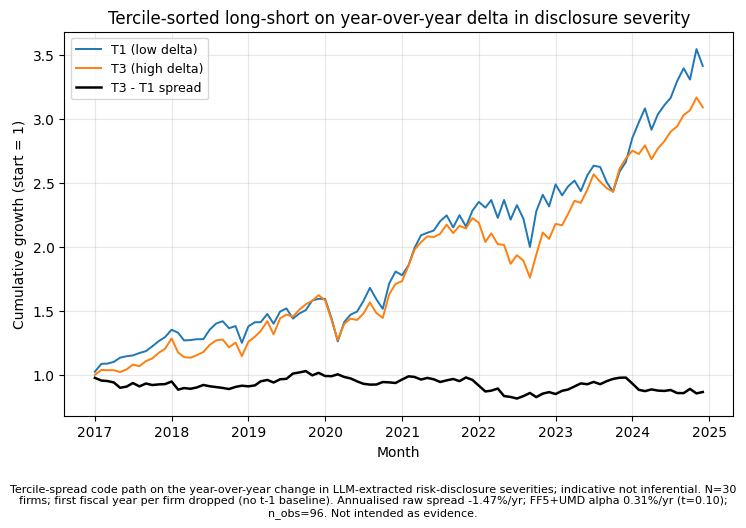

In [11]:
# plot_delta_spread saves the PDF (the headline deliverable at FIGURE_OUT).
# IPython cannot embed PDF inline, so we also render a PNG sidecar for the
# notebook display (gitignored; regenerated on every `make demo`).
plot_delta_spread(panel, summary, out_path=FIGURE_OUT)
png_path = FIGURE_OUT.with_suffix('.png')
plot_delta_spread(panel, summary, out_path=png_path)
display(Image(filename=str(png_path)))


## Caveats

- **Power**: 30 firms split across 3 terciles leaves 10 firms per leg, statistically thin.
- **Severity validity**: severities are LLM (or LM) judgements of disclosure language; not validated against expert ratings or external risk benchmarks.
- **Taxonomy**: the 10-theme list is hand-listed and illustrative; production use would require a data-driven taxonomy.
- **Reproducibility**: `provenance.json` + `extraction_prompt.md` + the `corpus.ndjson.gz` SHA chain enable a full audit of how every severity was produced.


## What to try next: the quantlet family as a map

Each quantlet isolates one methodological axis while holding all others constant.

- **01**: level signal on the same composite_severity panel; the natural pair-comparison for this quantlet, since the only difference is level vs first-difference of the same scalar signal.
- **02**: LM dictionary baseline; replaces LLM scores with Loughran-McDonald counts to isolate the semantic vs lexical contribution.
- **03**: decile granularity on the level signal; tests whether finer sorting changes spread magnitude or stability.
- **05**: FF3 vs FF5+UMD risk basis; tests whether RMW, CMA, and UMD materially change the residual.
- **06**: corpus distribution inspection; a diagnostic that should be read before interpreting any downstream result.
- **07**: skip-month formation lag on the level signal; tests sensitivity to the assumed implementation lag.
- **08**: within-sector demean; isolates whether the signal is driven by cross-sector or within-sector dispersion.
- **09**: rolling beta; tests whether alpha is stable over time or concentrated in specific subperiods.
- **10**: long-only T3; tests whether the return comes from the long leg, the short leg, or both.

No quantlet proves anything alone; the family is an axis-by-axis robustness map, not an evidence chain.


## Reproduction

```
git clone <repo>
cd 04_NarrativeRisk_DeltaSeverity
make data                  # fetch third-party data + regenerate seed-pinned inputs
make demo                  # this notebook -> delta_severity_summary.csv + delta_severity_spread.pdf
make test-all              # quantlet test suite
```
